# 02 - Model Training

Training YOLOv8n on the Construction Site Safety dataset.

- **Runtime**: Google Colab T4 GPU
- **Model**: YOLOv8n (nano) — pretrained on COCO
- **Dataset**: 2,801 images, 10 classes
- **Epochs**: 100 with early stopping (patience=10)


In [1]:
import torch
print(f"GPU available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name      : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


GPU available : True
GPU name      : Tesla T4
GPU memory    : 15.6 GB


## 1. Setup

In [2]:
# Install dependencies
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 79.6 MB/s eta 0:00:00


In [ ]:
import os
import torch
from pathlib import Path
from ultralytics import YOLO

# Check GPU availability
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB')

In [3]:
import zipfile
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

ZIP_PATH    = Path('/content/drive/MyDrive/Task/archive.zip')
DATASET_DIR = Path('/content/css-data')

if not DATASET_DIR.exists():
    print("Unzipping archive.zip ...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('/content/')
    print("Done!")

print(f"Dataset exists : {DATASET_DIR.exists()}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset exists : True


Verify splits

In [4]:
for split in ["train", "valid", "test"]:
    img_dir = DATASET_DIR / split / "images"
    n = len(list(img_dir.glob("*"))) if img_dir.exists() else 0
    print(f"  {split:>6}: {n} images")


   train: 2605 images
   valid: 114 images
    test: 82 images


Create data.yaml

In [5]:
import yaml

DATA_YAML = Path('/content/data.yaml')

config = {
    'path' : str(DATASET_DIR),
    'train': 'train/images',
    'val'  : 'valid/images',
    'test' : 'test/images',
    'nc'   : 10,
    'names': [
        'Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask',
        'NO-Safety Vest', 'Person', 'Safety Cone',
        'Safety Vest', 'machinery', 'vehicle'
    ]
}

with open(DATA_YAML, 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

print("data.yaml created:")
print(DATA_YAML.read_text())


data.yaml created:
names:
- Hardhat
- Mask
- NO-Hardhat
- NO-Mask
- NO-Safety Vest
- Person
- Safety Cone
- Safety Vest
- machinery
- vehicle
nc: 10
path: /content/css-data
test: test/images
train: train/images
val: valid/images



## Train

**Why YOLOv8n?**
- Nano model: 3.2M parameters, fastest inference
- Fits in T4 GPU memory with batch=16
- Good enough accuracy for safety monitoring (mAP@50 ~0.80)

**Why these hyperparameters?**
- `patience=10` — stop early if no improvement (saves time)
- `mosaic=1.0` — mosaic augmentation: combines 4 images into 1 (improves small object detection)
- `flipud=0.0` — workers are never upside down
- `fliplr=0.5` — horizontal flip is realistic


In [6]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

results = model.train(
    data    = str(DATA_YAML),
    epochs  = 100,
    imgsz   = 640,
    batch   = 16,
    patience= 10,
    lr0     = 0.01,
    lrf     = 0.01,
    flipud  = 0.0,
    fliplr  = 0.5,
    mosaic  = 1.0,
    project = '/content/runs',
    name    = 'safety_monitor',
    exist_ok= True,
)
print("Training complete!")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, i

Training curves

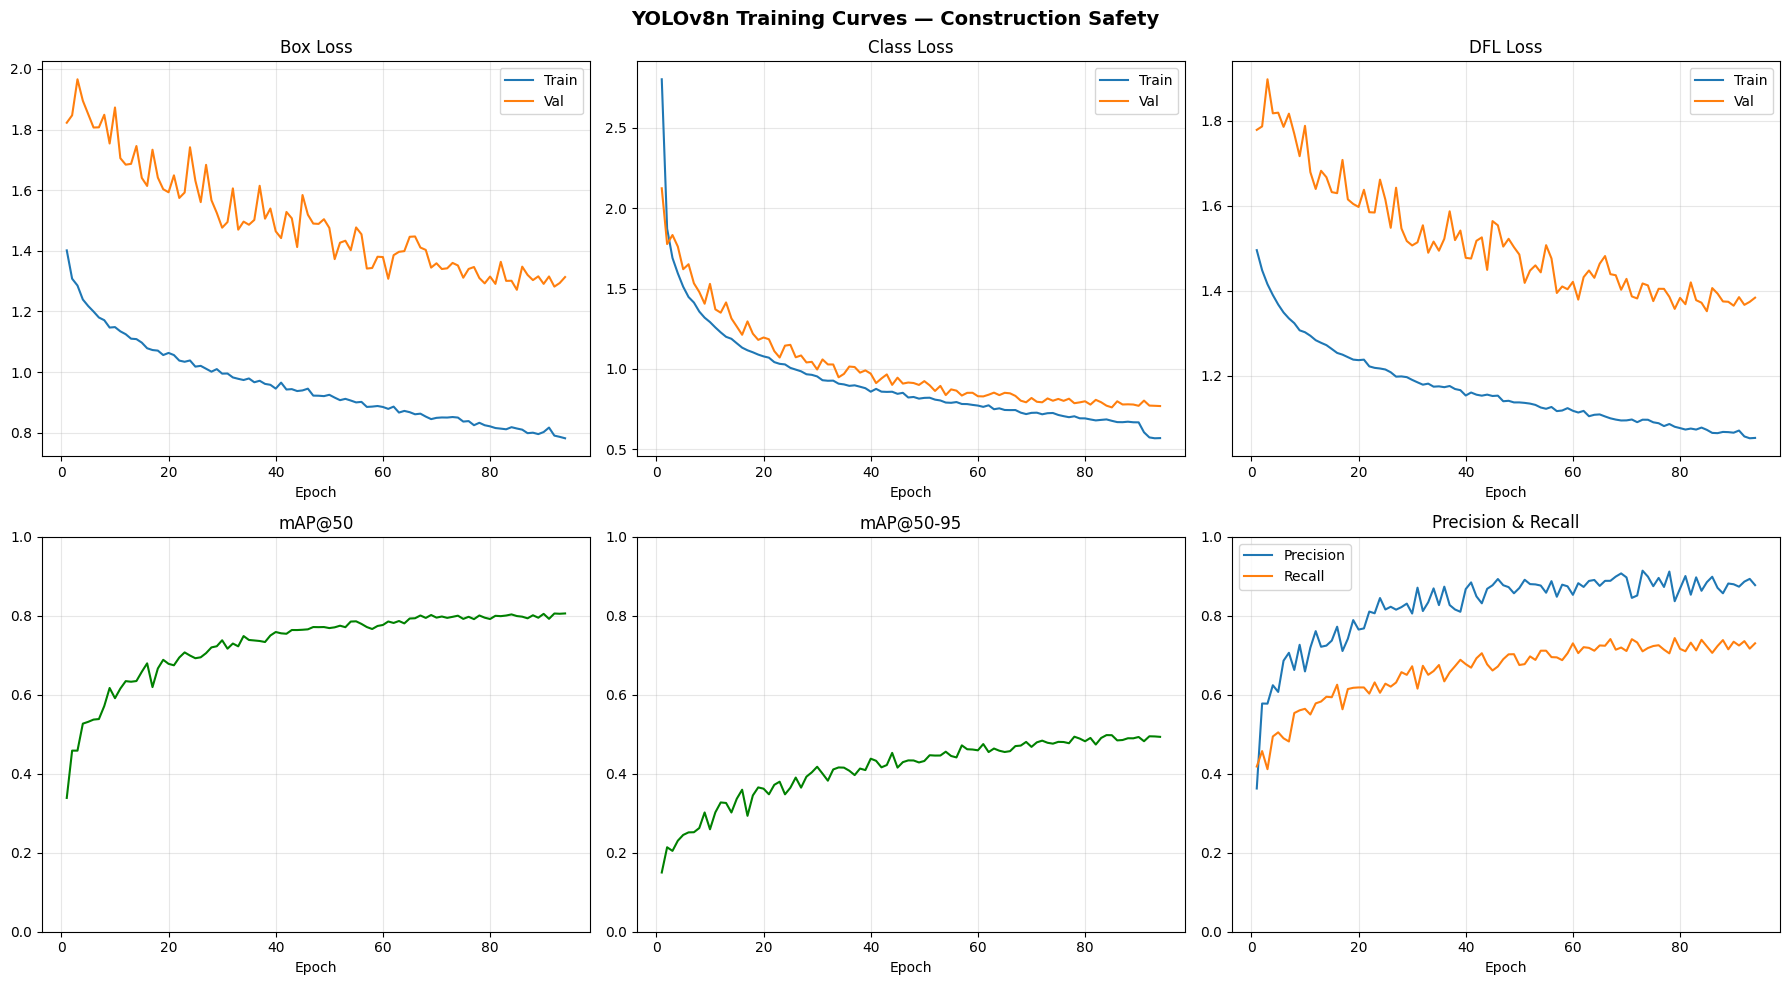

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/runs/safety_monitor/results.csv')
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0,0].plot(df['epoch'], df['train/box_loss'], label='Train')
axes[0,0].plot(df['epoch'], df['val/box_loss'],   label='Val')
axes[0,0].set_title('Box Loss')
axes[0,0].legend()

axes[0,1].plot(df['epoch'], df['train/cls_loss'], label='Train')
axes[0,1].plot(df['epoch'], df['val/cls_loss'],   label='Val')
axes[0,1].set_title('Class Loss')
axes[0,1].legend()

axes[0,2].plot(df['epoch'], df['train/dfl_loss'], label='Train')
axes[0,2].plot(df['epoch'], df['val/dfl_loss'],   label='Val')
axes[0,2].set_title('DFL Loss')
axes[0,2].legend()

axes[1,0].plot(df['epoch'], df['metrics/mAP50(B)'],    color='green')
axes[1,0].set_title('mAP@50')
axes[1,0].set_ylim(0, 1)

axes[1,1].plot(df['epoch'], df['metrics/mAP50-95(B)'], color='green')
axes[1,1].set_title('mAP@50-95')
axes[1,1].set_ylim(0, 1)

axes[1,2].plot(df['epoch'], df['metrics/precision(B)'], label='Precision')
axes[1,2].plot(df['epoch'], df['metrics/recall(B)'],    label='Recall')
axes[1,2].set_title('Precision & Recall')
axes[1,2].set_ylim(0, 1)
axes[1,2].legend()

for ax in axes.flat:
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)

plt.suptitle('YOLOv8n Training Curves — Construction Safety',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Best metrics

In [8]:
best_idx = df['metrics/mAP50(B)'].idxmax()

print("=" * 40)
print("BEST MODEL METRICS")
print("=" * 40)
print(f"Best epoch   : {int(df.loc[best_idx, 'epoch'])}")
print(f"mAP@50       : {df.loc[best_idx, 'metrics/mAP50(B)']:.4f}")
print(f"mAP@50-95    : {df.loc[best_idx, 'metrics/mAP50-95(B)']:.4f}")
print(f"Precision    : {df.loc[best_idx, 'metrics/precision(B)']:.4f}")
print(f"Recall       : {df.loc[best_idx, 'metrics/recall(B)']:.4f}")


BEST MODEL METRICS
Best epoch   : 94
mAP@50       : 0.8060
mAP@50-95    : 0.4935
Precision    : 0.8777
Recall       : 0.7304


Save to Drive

In [ ]:
import shutil

src  = Path('/content/runs/safety_monitor/weights/best.pt')
dest = Path('/content/drive/MyDrive/Task/best.pt')
dest3 = Path('../models/best.pt')


shutil.copy2(src, dest3)

print(f"Saved to Drive: {dest}")
print("Download this file and put it in your models/ folder")


FileNotFoundError: [Errno 2] No such file or directory: '../models/best.pt'